# **2.4 Calculus**
In deep learning, we “train” models, continuously updating them so that they get better and better as they are exposed to more and more data. **Typically,
getting better means minimizing a loss function—a score that measures “how bad the model is.”**
Ultimately, what we really care about is creating a model that performs well on data it has never seen before. **However, “training” a model only allows us to
fit the model to the data we actually have access to.** Therefore, we can break down the task of fitting a model into two key problems:<br><br>
• **Optimization: The process of fitting a model to observed data;**<br>
• **Generalization: Mathematical principles and the wisdom of practitioners can guide us in creating models whose validity extends beyond the training dataset itself.**

## **2.4.1 Derivatives and Differentials**
In short, for each parameter, if we increase or decrease that parameter by an infinitesimally small amount, we
can determine how quickly the loss will increase or decrease,<br><br>
Suppose we have a function $f : \mathbb{R} \to \mathbb{R}$ whose input and output are both scalars. If the derivative of $f$ exists, this limit is defined as
##### (2.4.1)
$$f^{(1)}(x) = \lim_{h \to 0}\frac{f\left(x+h\right)-f\left(x\right)}{h}$$<br><br>
**If $f^{(1)}(a)$ exists, then $f$ is said to be differentiable at a. If $f$ is differentiable at every point in an interval, then the
function is differentiable on that interval.** We can interpret the derivative $f^{(1)}(x)$ in [(2.4.1)](#241) as the instantaneous rate of change of $f(x)$ with respect to $x$.
This so-called instantaneous rate of change is based on a small change $h$ in $x$, where $h$ approaches 0.<br><br>
To better explain derivatives, let's conduct an experiment.

In [1]:
%matplotlib inline
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

def f(x):
    return 3 * x ** 2 - 4 * x

By setting $x$ = 1 and letting $h$ approach 0, we see from [(2.4.1)](#241) $\frac{f\left(x+h\right)-f\left(x\right)}{h}$ that shows that when $x$ = 1, the derivative $u^{(1)}$ is 2.

In [2]:
def numerical_lim(f, x, h):
    return (f(x + h) - f(x)) / h

h = 0.1
for i in range(5):
    print(f'h={h:.5f}, numerical limit={numerical_lim(f, 1, h):.5f}')
    h *= 0.1

h=0.10000, numerical limit=2.30000
h=0.01000, numerical limit=2.03000
h=0.00100, numerical limit=2.00300
h=0.00010, numerical limit=2.00030
h=0.00001, numerical limit=2.00003


Given $y = f(x)$, where $x$ and $y$ are the independent and dependent variables of the function $f$, respectively, the following expressions are equivalent:
##### (2.4.2)
$$f'(x) = y' = \frac{dy}{dx} = \frac{df}{dx} = \frac{d}{dx}f(x) = Df(x) = D_{x}f(x)$$<br><br>
The symbols $\frac{d}{dx}$ and $D$ are differential operators, representing the differential operation. We can use the following rules to find the derivatives of common functions:<br><br>
• $DC$ = 0 (where $C$ is a constant)<br><br>
• $Dx^{n} = nx^{n−1}$ (power rule, where n is any real number)<br><br>
• $De^{x} = e^{x}$<br><br>
• $D\ln(x) = 1/x$<br><br>
The following rules are useful for differentiating a function composed of several common functions. Suppose that functions $f$ and $g$ are both differentiable, and $C$ is a constant. Then:
##### (2.4.3) The Rule for Multiplying Constants
$$\frac{d}{dx}[Cf(x)] = C\frac{d}{dx}f(x)$$<br><br>
##### (2.4.4) The Rule for Addition
$$\frac{d}{dx}[f(x) + g(x)] = \frac{d}{dx}f(x) + \frac{d}{dx}g(x)$$<br><br>
##### (2.4.5) The Rule for Multiplication
$$\frac{d}{dx}[f(x)g(x)] = g(x)\frac{d}{dx}[f(x)] + f(x)\frac{d}{dx}[g(x)]$$<br><br>
##### (2.4.5) The Rule for Division
$$\frac{d}{dx}\left[\frac{f(x)}{g(x)}\right] = \frac{g(x)\frac{d}{dx}[f(x)] - f(x)\frac{d}{dx}[g(x)]}{[g(x)]^{2}}$$<br><br>
To visualize this interpretation of derivatives, we will use matplotlib, a popular plotting library in Python. To configure
the properties for generating plots with matplotlib, we need to define several functions. Below, the `use_svg_display` function instructs the matplotlib
library to output SVG charts for clearer visuals.<br><br>
Note that **the #@save comment is a special marker that saves the corresponding function, class, or statement in the d2l package. Therefore, you can call them directly in the future
without having to redefine them**.

In [3]:
def use_svg_display(): #@save
    """
    Displaying Plots in Jupyter Using the SVG Format
    """
    backend_inline.set_matplotlib_formats('svg')

We define the `set_figsize` function to **set the chart size**.

In [4]:
def set_figsize(figsize=(3.5, 2.5)): #@save
    """
    Setting the size of matplotlib plots
    """
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize

The `set_axes` function below is used to **set the properties of the axes in plots generated by matplotlib**.

In [5]:
#@save
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """
    Configuring matplotlib Axes
    """
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()

Using these three functions for graphical configuration, define a `plot` function to draw multiple curves concisely, since we will need to visualize many curves throughout the book.

In [6]:
#@save
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear',yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """
    Plotting Data Points
    """
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # If X has an axis, output True
    def has_one_axis(X):
        return (hasattr(X, 'ndim') and X.ndim == 1 or isinstance(X, list) and not hasattr(X[0], '__len__'))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

Now we can plot the function $u = f(x)$ and its tangent line at $x$ = 1, $y = 2x − 3$, where the coefficient 2 is the slope of the tangent line.

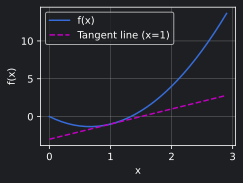

In [7]:
x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

## **2.4.2 Partial derivative**
In deep learning, functions typically depend on many variables. Therefore, we need to generalize the concept of differentiation to multivariate functions.<br><br>
Let $y = f(x₁, x₂, ..., xₙ)$ be a function of n variables. The partial derivative of $y$ with respect to the i-th argument $x_{i}$ is:
##### (2.4.7) The definition of derivative
$$\frac{\partial y}{\partial x_i} = \lim\frac{f(x_1,...,x_{i-1},x_{i}+h,x_{i+1},...,x_{n}) - f(x_1,...,x_{i},...,x_{n})}{h}$$<br><br>
To compute $\frac{\partial{y}}{\partial{x_i}}$, we can simply treat $x_1, ..., x_{i−1}, x_{i+1}, ..., x_n$ as constants and compute the derivative of $y$ with respect to $x_i$.
##### (2.4.8) Representations of Partial Derivatives
$$\frac{\partial{y}}{\partial{x_i}} = \frac{\partial{f}}{\partial{x_i}} = f_{x_i} = f_i = D_{i}f = D_{x_i}f$$<br><br>

## **2.4.3 Gradient**
We can combine the partial derivatives of a multivariable function with respect to all its variables to obtain the gradient vector of that function. Specifically, let
the function $f : \mathbb{R}^n \to \mathbb{R}$ take an $n$-dimensional vector $x = [x_1, x_2, \ldots, x_n]^T$ as input and return a scalar. The gradient of the function $f(x)$ with respect to $x$
is a vector containing $n$ partial derivatives:
##### (2.4.9) The definition of Gradient
$$\nabla_{x}f(x) = \left[\frac{\partial{f(x)}}{\partial{x_1}},\frac{\partial{f(x)}}{\partial{x_2}},...\frac{\partial{f(x)}}{\partial{x_n}}\right]^T$$<br><br>
Let $x$ be an n-dimensional vector. The following rules are frequently used when differentiating multivariable functions:<br><br>
**• For all $A ∈ \mathbb{R}^{m×n}, \nabla_{x}Ax = A^T$<br><br>
• For all $A ∈ \mathbb{R}^{n×m}, \nabla_{x}x^{T}A = A$<br><br>
• For all $A ∈ \mathbb{R}^{n×n}, \nabla_{x}x^{T}Ax = (A + A^{T})x$<br><br>
• $\nabla_{x}||x||^{2} = \nabla_{x} x^{T} x = 2x$<br><br>**
## **2.4.2 Partial derivative**
Multivariable functions are usually composite, so it is
difficult to apply any of the above rules to differentiate them. Fortunately, the chain rule can be used to differentiate composite functions.
Suppose the functions $y = f(u)$ and $u = g(x)$ are both differentiable. By the chain rule:
##### (2.4.10) The Chain Reaction Principle
$$\frac{dy}{dx} = \frac{dy}{du}\frac{du}{dx}$$<br><br>
Suppose $y$ is a differentiable function with variables $u₁, u₂, ..., u_m$, where
each differentiable function $u_i$ has variables $x₁, x₂, ..., x_n$. Note that $y$ is a function of $x₁, x₂, ..., x_n$. For any $i$ = 1, 2, ..., n, the chain rule states that:
##### (2.4.11) The General Chain Reaction Principle
$$\frac{dy}{dx_i} = \frac{dy}{du_1}\frac{du_1}{dx_i}+\frac{dy}{du_2}\frac{du_2}{dx_i}+...+\frac{dy}{du_m}\frac{du_m}{dx_i}$$<br><br>